In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df_table = pd.read_csv("MBH_table_final.csv")

In [5]:
df_table.tail()

,Galaxy,M_BH,M_BH_lower,M_BH_upper,sigma,Morph,Method,Source,Paper reference,MASSIVE?,BCG?
87,NGC4751,1400000000,1.300000e+09,1.500000e+09,355.4,E/S0,star,New,Rusli+13,NaN,NaN
88,NGC6861,2000000000,1.800000e+09,2.200000e+09,388.8,E/S0,star,New,Rustli+13,NaN,NaN
89,NGC5419,10000000000,9.200000e+09,1.080000e+10,350.0,E,star tri,New,Neureiter+23,NaN,NaN
90,NGC 3258,2200000000,2.000000e+09,2.400000e+09,232.0,E,star axi,New,Waters+24,NaN,NaN
91,NGC 4261,1670000000,3.400000e+08,4.800000e+08,261.0,E,gas,New,Boizelle+21,NaN,NaN


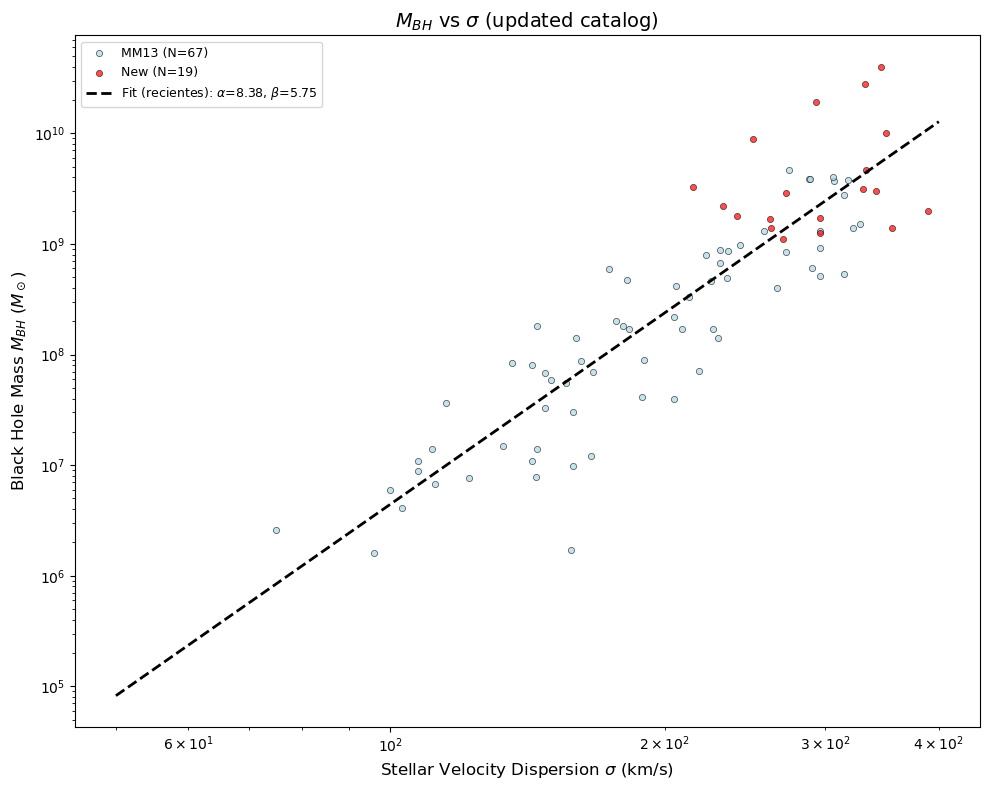

Fit con galaxias recientes (N=92):
  alpha = 8.376
  beta  = 5.747


In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar Velocity Dispersion $\sigma$ (km/s)", fontsize=12)
ax.set_ylabel("Black Hole Mass $M_{BH}$ ($M_\odot$)", fontsize=12)
ax.set_title("$M_{BH}$ vs $\sigma$ (updated catalog)", fontsize=14)

# Colores para cada categoría
colors = { "MM13": "lightblue","New":  "red",}

labels = {"MM13": "MM13","New":"New",}

# Plotear cada categoría por separado
cuenta=0
for Source in ["MM13", "New"]:
    sub = df_table[df_table["Source"] == Source]
    if len(sub) > 0:
        ax.scatter(sub["sigma"], sub["M_BH"],
                   color=colors[Source], s=20, alpha=0.7,
                   edgecolors="black", linewidths=0.5,
                   label=f"{labels[Source]} (N={len(sub)})")
        

# Anotar nombres de galaxias
#for i in range(len(df_plot)):
 #   row = df_plot.iloc[i]
  #  ax.annotate(row["Galaxy"],
   #             (row["sigma"], row["mbh"]),
    #            xytext=(3, 3), textcoords="offset points",
     #           fontsize=6)

#Fit solo con galaxias recientes 
# (extra_recent + LM24_new + MM13_updated+originales no actualizadas)
logx = np.log10(df_table["sigma"] / 200.0)
logy = np.log10(df_table["M_BH"])
beta, alpha = np.polyfit(logx, logy, 1)

# Dibujar línea del fit
sigma_grid = np.linspace(50, 400, 200)
x_grid = np.log10(sigma_grid / 200.0)
y_fit = alpha + beta * x_grid
ax.plot(sigma_grid, 10**y_fit, "k--", linewidth=2,
        label=f"Fit (recientes): $\\alpha$={alpha:.2f}, $\\beta$={beta:.2f}")

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Fit con galaxias recientes (N={len(df_table)}):")
print(f"  alpha = {alpha:.3f}")
print(f"  beta  = {beta:.3f}")


In [11]:
df_table[df_table["Galaxy"]=="NGC4889"]

,Galaxy,M_BH,M_BH_lower,M_BH_upper,sigma,Morph,Method,Source,Paper reference,MASSIVE?,BCG?
56,NGC4889,20170000000,NaN,NaN,337.0,E,star,MM13_updated,McConnell+11,Y,NaN


In [19]:
len(ax[0].get_xdata())

TypeError: 'Axes' object is not subscriptable